# Dataset Inspection


## Setup


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

DATASET_DIR = Path("dataset")
SPLITS = ["train", "valid", "test"]

random.seed(42)
np.random.seed(42)


## Load Metadata


In [2]:
class_df = pd.read_csv(DATASET_DIR / "class_dict.csv")
meta_df = pd.read_csv(DATASET_DIR / "metadata.csv")

print("Class dictionary:")
display(class_df)

print("Metadata sample:")
display(meta_df.head())

if "split" in meta_df.columns:
    print("Metadata split counts:")
    print(meta_df["split"].value_counts())


Class dictionary:


,name,r,g,b
0,urban_land,0,255,255
1,agriculture_land,255,255,0
2,rangeland,255,0,255
3,forest_land,0,255,0
4,water,0,0,255
5,barren_land,255,255,255
6,unknown,0,0,0


Metadata sample:


,image_id,split,sat_image_path,mask_path
0,100694,train,train/100694_sat.jpg,train/100694_mask.png
1,102122,train,train/102122_sat.jpg,train/102122_mask.png
2,10233,train,train/10233_sat.jpg,train/10233_mask.png
3,103665,train,train/103665_sat.jpg,train/103665_mask.png
4,103730,train,train/103730_sat.jpg,train/103730_mask.png


Metadata split counts:
split
train    803
test     172
valid    171
Name: count, dtype: int64


## File Structure And Pairing


In [3]:
def list_pairs(split_dir: Path):
    sats = sorted(split_dir.glob("*_sat.jpg"))
    masks = sorted(split_dir.glob("*_mask.png"))

    sat_ids = {p.stem.replace("_sat", "") for p in sats}
    mask_ids = {p.stem.replace("_mask", "") for p in masks}

    missing_masks = sorted(sat_ids - mask_ids)
    missing_sats = sorted(mask_ids - sat_ids)

    return {
        "sat_count": len(sats),
        "mask_count": len(masks),
        "missing_masks": missing_masks,
        "missing_sats": missing_sats,
        "sat_paths": sats,
        "mask_paths": masks,
    }

for split in SPLITS:
    split_dir = DATASET_DIR / split
    info = list_pairs(split_dir)
    print()
    print(f"[{split}] sat: {info['sat_count']} | mask: {info['mask_count']}")
    if info["missing_masks"]:
        print(f"  Missing masks for {len(info['missing_masks'])} ids (showing up to 5): {info['missing_masks'][:5]}")
    if info["missing_sats"]:
        print(f"  Missing sats for {len(info['missing_sats'])} ids (showing up to 5): {info['missing_sats'][:5]}")



[train] sat: 803 | mask: 803

[valid] sat: 171 | mask: 0
  Missing masks for 171 ids (showing up to 5): ['105036', '107780', '108490', '127801', '128240']

[test] sat: 172 | mask: 0
  Missing masks for 172 ids (showing up to 5): ['100877', '103215', '103742', '110224', '112946']


## Image And Mask Size Checks


In [4]:
def sample_paths(paths, n=30):
    if len(paths) <= n:
        return paths
    return random.sample(paths, n)

for split in SPLITS:
    split_dir = DATASET_DIR / split
    info = list_pairs(split_dir)
    sample_sats = sample_paths(info["sat_paths"], n=30)

    sizes = []
    mismatched = 0
    missing = 0

    for sat_path in sample_sats:
        mask_path = split_dir / sat_path.name.replace("_sat.jpg", "_mask.png")
        if not mask_path.exists():
            missing += 1
            continue
        with Image.open(sat_path) as img:
            img_size = img.size
        with Image.open(mask_path) as msk:
            mask_size = msk.size
        sizes.append(img_size)
        if img_size != mask_size:
            mismatched += 1

    size_counts = pd.Series(sizes).value_counts()

    print()
    print(f"[{split}] Sampled {len(sample_sats)} pairs")
    print(f"Missing masks in sample: {missing}")
    print("Image size counts (sample):")
    print(size_counts)
    print(f"Mismatched image/mask sizes (sample): {mismatched}")



[train] Sampled 30 pairs
Missing masks in sample: 0
Image size counts (sample):
(2448, 2448)    30
Name: count, dtype: int64
Mismatched image/mask sizes (sample): 0

[valid] Sampled 30 pairs
Missing masks in sample: 30
Image size counts (sample):
Series([], Name: count, dtype: int64)
Mismatched image/mask sizes (sample): 0

[test] Sampled 30 pairs
Missing masks in sample: 30
Image size counts (sample):
Series([], Name: count, dtype: int64)
Mismatched image/mask sizes (sample): 0


## Mask Color Validation


In [5]:
color_map = {(row.r, row.g, row.b): row["name"] for _, row in class_df.iterrows()}
valid_colors = set(color_map.keys())

for split in SPLITS:
    split_dir = DATASET_DIR / split
    info = list_pairs(split_dir)
    sample_masks = sample_paths(info["mask_paths"], n=20)

    found_colors = set()
    for mask_path in sample_masks:
        with Image.open(mask_path) as m:
            arr = np.array(m.convert("RGB"))
        colors = np.unique(arr.reshape(-1, 3), axis=0)
        found_colors.update({tuple(c) for c in colors})

    unknown = sorted(found_colors - valid_colors)

    print()
    print(f"[{split}] Unique colors found (sample): {len(found_colors)}")
    if unknown:
        print(f"  Unknown colors not in class_dict.csv (showing up to 10): {unknown[:10]}")
    else:
        print("  All sampled mask colors match class_dict.csv")



[train] Unique colors found (sample): 7
  All sampled mask colors match class_dict.csv

[valid] Unique colors found (sample): 0
  All sampled mask colors match class_dict.csv

[test] Unique colors found (sample): 0
  All sampled mask colors match class_dict.csv


## Visual Samples


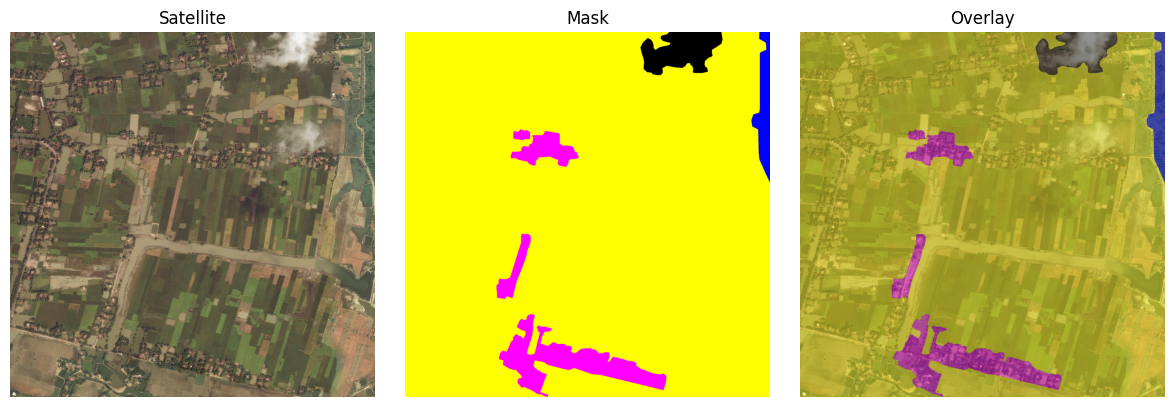

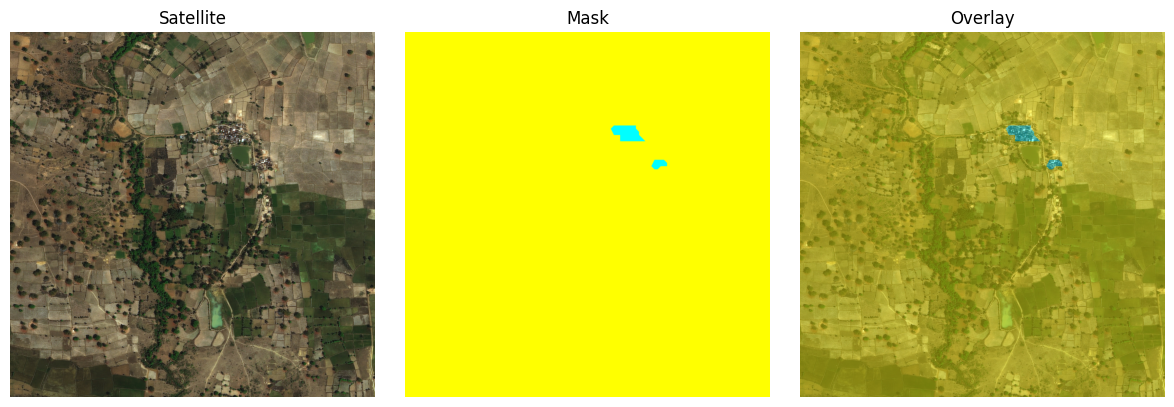

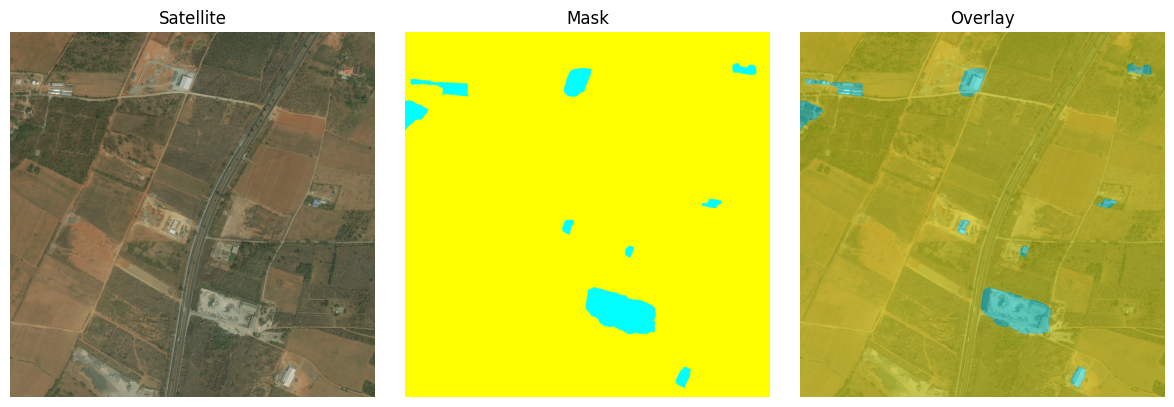

In [8]:
def show_sample(split, n=20):
    split_dir = DATASET_DIR / split
    info = list_pairs(split_dir)
    sample_sats = sample_paths(info["sat_paths"], n=n)

    for sat_path in sample_sats:
        mask_path = split_dir / sat_path.name.replace("_sat.jpg", "_mask.png")

        with Image.open(sat_path) as img:
            img = img.convert("RGB")
        with Image.open(mask_path) as msk:
            msk = msk.convert("RGB")

        img_arr = np.array(img)
        msk_arr = np.array(msk)

        overlay = (0.6 * img_arr + 0.4 * msk_arr).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img_arr)
        axes[0].set_title("Satellite")
        axes[0].axis("off")

        axes[1].imshow(msk_arr)
        axes[1].set_title("Mask")
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Overlay")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

show_sample("train", n=3)


## Metadata Consistency Checks


In [9]:
def exists_from_meta(row):
    sat_path = DATASET_DIR / row["sat_image_path"]
    if pd.isna(row["mask_path"]):
        return sat_path.exists(), False
    mask_path = DATASET_DIR / row["mask_path"]
    return sat_path.exists(), mask_path.exists()

if {"sat_image_path", "mask_path"}.issubset(meta_df.columns):
    sat_exists = []
    mask_exists = []
    for _, row in meta_df.iterrows():
        s_ok, m_ok = exists_from_meta(row)
        sat_exists.append(s_ok)
        mask_exists.append(m_ok)

    meta_df = meta_df.copy()
    meta_df["sat_exists"] = sat_exists
    meta_df["mask_exists"] = mask_exists

    print("Missing files referenced by metadata:")
    print("  sat missing:", (~meta_df["sat_exists"]).sum())
    print("  mask missing:", (~meta_df["mask_exists"]).sum())

    display(meta_df[~meta_df["sat_exists"] | ~meta_df["mask_exists"]].head())
else:
    print("metadata.csv does not contain sat_image_path and mask_path columns.")

Missing files referenced by metadata:
  sat missing: 0
  mask missing: 343


,image_id,split,sat_image_path,mask_path,sat_exists,mask_exists
803,105036,valid,valid/105036_sat.jpg,NaN,True,False
804,107780,valid,valid/107780_sat.jpg,NaN,True,False
805,108490,valid,valid/108490_sat.jpg,NaN,True,False
806,127801,valid,valid/127801_sat.jpg,NaN,True,False
807,128240,valid,valid/128240_sat.jpg,NaN,True,False


## Class Distribution

In [ ]:
color_to_class = {(row.r, row.g, row.b): row["name"] for _, row in class_df.iterrows()}
class_names = class_df["name"].tolist()

pixel_counts = {name: 0 for name in class_names}

train_dir = DATASET_DIR / "train"
train_info = list_pairs(train_dir)

for mask_path in train_info["mask_paths"]:
    with Image.open(mask_path) as m:
        arr = np.array(m.convert("RGB"))
    pixels = arr.reshape(-1, 3)
    colors, counts = np.unique(pixels, axis=0, return_counts=True)
    for color, count in zip(colors, counts):
        name = color_to_class.get(tuple(color))
        if name:
            pixel_counts[name] += count

total_pixels = sum(pixel_counts.values())
pixel_df = pd.DataFrame({
    "class": list(pixel_counts.keys()),
    "pixel_count": list(pixel_counts.values()),
})
pixel_df["percentage"] = (pixel_df["pixel_count"] / total_pixels * 100).round(2)
pixel_df = pixel_df.sort_values("percentage", ascending=False).reset_index(drop=True)

print("Class pixel distribution across all training masks:")
display(pixel_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pixel_df["class"], pixel_df["percentage"])
ax.set_ylabel("% of total pixels")
ax.set_title("Class Distribution (train masks)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 